# ML 4강 실습 정리: Titanic EDA (Pandas + Seaborn)

이 노트북은 `ML/20250326.md`의 4강 흐름에 맞춰 구성했다.

- 목표 1: `head/info/shape/describe`로 데이터 전체 구조 빠르게 파악
- 목표 2: 결측치 확인 및 `datadict`로 전처리 우선순위 설정
- 목표 3: 단변수/이변수 시각화로 생존율 관련 가설 도출
- 목표 4: 상관행렬 히트맵으로 수치형 변수 관계 점검

> 핵심: 상관은 인과가 아니며, EDA 결과는 모델링 전 가설 생성 단계다.

## 진행 원칙 (지금부터)

이 노트북은 **마크다운 셀 추가/보강을 기본 전제**로 디벨롭한다.

- 코드셀은 실행 재현성을 위해 최소 수정
- 개념 설명, 해석 포인트, 실습 의도는 마크다운으로 누적
- 4강 본문(`ML/20250326.md`)과 섹션 매칭을 유지

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the Titanic dataset
titanic = sns.load_dataset('titanic')
print(titanic.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


## 영문 강의자료 1:1 매칭 브리핑 (4강 EDA 기준)

아래는 제공한 영문 슬라이드/스크립트를 **빠짐없이** 4강 문맥으로 대응한 브리핑이다.

### A. 강의 타이틀/개요 매칭

- **Machine Learning**
  - 대응: 4강은 모델 학습 자체보다, 모델 직전 단계인 **EDA/전처리 기초**를 다루는 머신러닝 실습 파트.

- **Exploratory Data Analysis / Exploratory Data Analysis (EDA)**
  - 대응: 탐색적 데이터 분석은 문제정의 후 초기 분석에서 수행하는 통계적 접근.
  - 강의 의도: 모델 선택 전에 데이터 구조/결측/분포/관계를 파악해 분석 방향을 정한다.

### B. EDA 설명 문장별 대응

- **A statistical approach used in initial data investigations (Pattern discovery, Anomaly detection, Hypothesis testing)**
  - 대응: 초기 데이터 조사 단계의 통계적 접근.
  - 핵심: 패턴 발견, 이상치 탐지, 가설 점검.

- **Analysts to understand the data’s underlying structures, inform model choices, and find directions for further research and data analysis**
  - 대응: 데이터의 잠재 구조를 파악하고, 모델 선택 근거를 만들며, 후속 분석 방향을 도출.

- **By examining the distribution and values of data, the further understand the phenomena represented by the data and identify potential issues is possible**
  - 대응: 분포와 값의 범위를 확인해 현상을 더 정확히 이해하고 잠재 이슈(결측, 왜도, 비정상값)를 발견.

- **Discover diverse patterns that may not have emerged during the problem definition phase**
  - 대응: 문제정의 단계에서 보이지 않던 패턴을 EDA에서 추가 발견.

### C. EDA 4단계 체크리스트 매칭

- **Identify the purpose of the analysis and what variables are involved.**
  - 대응: 분석 목적/타깃/설명변수 정의 (`survived`를 타깃으로 가정).

- **Overall examination of the data (identifying anomalies, missing values, etc)**
  - 대응: `head`, `info`, `shape`, `describe`, `isnull().sum()`으로 전체 점검.

- **Observation of individual attribute values**
  - 대응: 단일 변수 분포/빈도 파악 (`countplot`, `histplot`).

- **Focus on the relationships between attributes (correlations, visualization)**
  - 대응: 변수 간 관계 탐색 (`groupby` 생존율, `boxplot`, 상관행렬 `heatmap`).

### D. Titanic 데이터셋 소개 문장 매칭

- **Titanic dataset is a widely used historical dataset in data science, to learn about exploratory data analysis and machine learning techniques.**
  - 대응: EDA/머신러닝 기초 교육에서 가장 널리 쓰는 표준 예시 데이터셋.

- **It consists of data from 891 of the 2,224 passengers and crew onboard the Titanic...**
  - 대응: 총 탑승객/승무원 2,224명 중 891명의 표본 데이터(Seaborn 제공 버전) 사용.

### E. 코드 도입부 매칭

```python
import seaborn as sns
import pandas as pd
# Load the Titanic dataset
titanic = sns.load_dataset('titanic')
print(titanic.columns)
```

- 대응: 실습 시작점. 데이터 로드 후 컬럼 확인으로 변수 사전 작성 준비.
- 출력 컬럼 15개 확인: `survived`, `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`, `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone`.

## 1) 데이터 로딩 및 1차 구조 파악 (4강 §14~§15)

먼저 타이타닉 데이터셋을 불러오고, 컬럼 구성을 확인한다.

- `head()` : 표의 앞부분으로 컬럼 의미를 직관적으로 확인
- `info()` : dtype, non-null count, 메모리 사용량 확인
- `shape` : 행/열 크기 확인
- `describe()` : 수치형 요약 통계 확인

In [2]:
# Display the first few entries of the dataset
print(titanic.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
# Display information about dataset
print(titanic.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None


In [4]:
print(titanic.shape)

(891, 15)


In [5]:
# Summary statistics for the dataset
print(titanic.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [6]:
# Check for missing values
print(titanic.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


## 영문 강의자료 변수 정의 전체 매칭 (15개 컬럼)

아래는 네가 준 영문 정의를 그대로 기준으로 4강 실습 맥락에 맞춰 정리한 매칭표다.

| 컬럼 | 영문 설명 대응 | 4강 해석 포인트 |
|---|---|---|
| `survived` | survived(1) / not(0) | 이진 타깃 변수 |
| `pclass` | 1st/2nd/3rd class | 사회경제적 계층 proxy |
| `sex` | passenger gender | 생존율 차이 크게 나는 핵심 범주 |
| `age` | passenger age | 결측 다수(177), 연속형 |
| `sibsp` | siblings/spouses aboard | 가족 동반 구조 |
| `parch` | parents/children aboard | 가족 동반 구조 |
| `fare` | ticket fare paid | 우측 왜도 큰 연속형 |
| `embarked` | C/Q/S embarkation port | 승선 항구 범주 |
| `class` | First/Second/Third | `pclass`의 범주형 버전 |
| `who` | man/woman/child | `sex`+연령 성격의 파생 범주 |
| `adult_male` | adult male boolean | 불리언 변수 |
| `deck` | cabin-derived deck A/B/C... | 결측 매우 큼(688) |
| `embark_town` | town of embarkation | `embarked`의 텍스트 확장 |
| `alive` | yes/no string version | `survived`의 문자열 버전 |
| `alone` | passenger alone boolean | 동승자 여부 |

### 참고: 표기 교정(자료 원문 오탈자 대응)

- `adult_male`가 원문 일부에서 붙어서 보이는 경우가 있음(`adult_malebool`) → 실제 컬럼은 `adult_male`.
- `embark`로 축약된 표기 등장 가능 → 실제 컬럼은 `embarked` 또는 `embark_town`.
- `survial`, `coorelation`, `Plcass` 등은 슬라이드 오탈자이며 의미는 각각 `survival`, `correlation`, `Pclass`.

## 2) 결측치 점검 및 Data Dictionary 작성 (4강 §16)

`isnull().sum()`으로 열별 결측치를 확인한 뒤, `datadict`를 만든다.

`datadict`에 넣는 핵심 정보:
- `DataType` : 변수 타입
- `MissingVal` : 결측 개수
- `NUnique` : 고유값 개수
- `Count` : 비결측 샘플 수

이 표를 기준으로 결측 대체, 열 제거, 인코딩 우선순위를 결정한다.

In [7]:
# identify missing values of the 15 columns,add the stats to the datadict
datadict = pd.DataFrame(titanic.dtypes)
datadict['MissingVal'] = titanic.isnull().sum()
datadict

,0,MissingVal
survived,int64,0
pclass,int64,0
sex,str,0
age,float64,177
sibsp,int64,0
parch,int64,0
fare,float64,0
embarked,str,2
class,category,0
who,str,0


In [8]:
datadict['NUnique']=titanic.nunique()
datadict['Count']=titanic.count()
datadict = datadict.rename(columns={0:'DataType'})
datadict


,DataType,MissingVal,NUnique,Count
survived,int64,0,2,891
pclass,int64,0,3,891
sex,str,0,2,891
age,float64,177,88,714
sibsp,int64,0,7,891
parch,int64,0,7,891
fare,float64,0,248,891
embarked,str,2,3,889
class,category,0,3,891
who,str,0,3,891


## 3) 타입별 요약 통계 분리 확인 (4강 EDA 절차 확장)

`describe(include=['object'])`로 범주형 요약을, `describe(include=['number'])`로 수치형 요약을 본다.

- 범주형: 최빈값(`top`)과 빈도(`freq`) 중심
- 수치형: 평균, 표준편차, 사분위수 중심

이 단계에서 변수별 분석 방법(막대그래프 vs 히스토그램)을 결정한다.

In [9]:
# get discripte statistcs on "object" datatypes
titanic.describe(include=['object'])

/tmp/ipykernel_29241/2161591120.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  titanic.describe(include=['object'])


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [10]:
# get discriptive statistcs on "number" datatypes
titanic.describe(include=['number'])

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4) 단변수 분포 시각화 (4강 §18)

- `histplot` : 연속형 변수(`age`, `fare`) 분포 확인
- `countplot` : 범주형 변수(`sex`, `pclass`, `embarked` 등) 빈도 확인

여기서 데이터 불균형 여부와 왜도(skewness) 같은 기초 신호를 먼저 확인한다.

### `kde=True` 해석 가이드 (4강 EDA 읽는 법)

`seaborn.histplot(..., kde=True)`에서 `kde=True`는 히스토그램 위에 **KDE(커널 밀도 추정) 곡선**을 함께 그리는 옵션이다.

- 히스토그램: 구간별 빈도(또는 밀도)
- KDE 곡선: 데이터 분포를 부드럽게 근사한 밀도 곡선

중요:
- 여기서 "fitting"은 정규분포 같은 모수를 딱 맞추는 모델 피팅이 아니라,
  데이터로부터 밀도 함수를 비모수적으로 추정해 곡선을 그리는 의미다.
- 즉, 학습 모델을 훈련하는 단계가 아니라 **분포 형태를 보기 위한 EDA 시각화 단계**다.

함께 보는 옵션:
- `bins`: 막대 구간 수
- `stat='density'`: KDE와 축 스케일 비교를 쉽게 함
- `common_norm=False`(hue 사용 시): 그룹별 분포 모양 비교에 유리

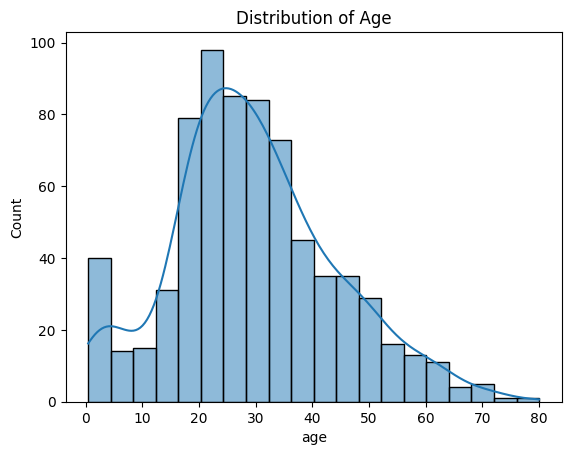

In [11]:
# Plotting distribution of Age
sns.histplot(titanic['age'].dropna(), kde=True)
plt.title('Distribution of Age')
plt.show()

## 5) 생존율 중심 이변수 탐색 (4강 §17, §19)

`groupby(...)["survived"].mean()`은 범주별 평균 생존율을 바로 보여준다.

- `pclass`, `sex`, `sibsp`, `parch`, `embarked`별 생존율 비교
- `boxplot(survived vs age/fare)`로 생존 집단 간 분포 차이 확인

이 단계 결과는 "어떤 변수가 생존과 관련이 큰가"에 대한 가설을 만든다.

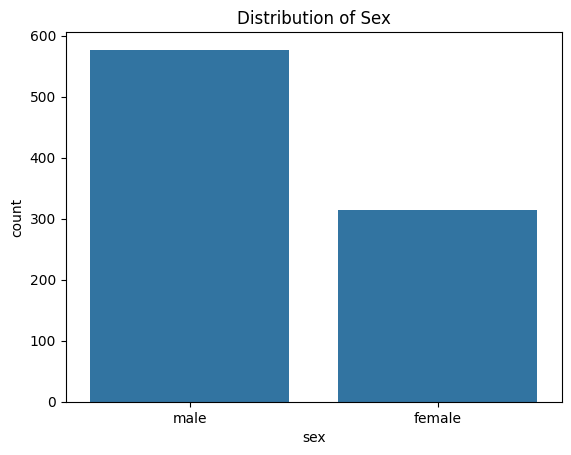

In [12]:
# Bar chart for categorical data
sns.countplot(x='sex', data=titanic)
plt.title('Distribution of Sex')
plt.show()

## 6) 종합 시각화: 빈도/분포 + 생존율 비교 (4강 §17~§19)

아래 셀은 4강에서 다룬 핵심 시각화를 한 번에 수행한다.

- `countplot` + `histplot`: 범주/연속 변수의 전체 분포 확인
- `groupby(...).mean().plot(kind='barh')`: 범주별 평균 생존율 비교
- `boxplot(survived vs age/fare)`: 생존 여부에 따른 연속형 분포 차이 확인

해석 포인트:
- 성별, 객실 등급, 운임은 생존과 관련성이 크게 나타나는 경향이 있다.
- 시각화 결과는 모델 전처리/특성 선택의 우선순위를 정하는 근거가 된다.

## 영문 강의자료 실습 코드 블록 순서 매칭 + 브리핑

아래는 제공된 영문 실습 코드를 **실행 흐름 그대로** 대응한 브리핑이다.

### 1) `print(titanic.head())`
- 의도: 표의 실제 샘플 행을 눈으로 확인.
- 확인 포인트:
  - 열의 성격(범주/수치/불리언/카테고리)
  - `deck` 등 결측 존재 여부 직관 확인.

### 2) `print(titanic.info())`
- 의도: 데이터 구조 메타정보 확인.
- 확인 포인트:
  - 891 rows, 15 columns
  - dtype 혼합: `bool`, `category`, `float64`, `int64`, `object`
  - 결측: `age(714 non-null)`, `embarked/embark_town(889)`, `deck(203)`

### 3) `print(titanic.describe())`
- 의도: 수치형 변수 기초 통계 확인.
- 확인 포인트:
  - 중심/산포: mean, std
  - 범위/분위수: min, 25%, 50%, 75%, max
  - `fare` 최대값(512.3292) 등 분포 치우침 후보 탐지.

### 4) `print(titanic.isnull().sum())`
- 의도: 결측치 개수 열 단위 집계.
- 확인 포인트:
  - `age=177`, `deck=688`, `embarked=2`, `embark_town=2`
  - 전처리 우선순위 설정 근거.

### 5) `datadict` 생성
```python
datadict = pd.DataFrame(titanic.dtypes)
datadict['MissingVal'] = titanic.isnull().sum()
datadict['NUnique'] = titanic.nunique()
datadict['Count'] = titanic.count()
datadict = datadict.rename(columns={0: 'DataType'})
```
- 의도: 변수 사전(Data Dictionary)로 구조/결측/고유값을 한 번에 관리.
- 실무 가치:
  - 변수 선택, 인코딩 방식, 결측 대체 전략을 설계할 때 기준표 역할.

### 6) Observation of individual attribute values (원문 표현 대응)
```python
figbi, axesbi = plt.subplots(2, 4, figsize=(16, 10))
titanic.groupby('pclass')['survived'].mean().plot(kind='barh', ...)
...
sns.boxplot(x='survived', y='age', ...)
sns.boxplot(x='survived', y='fare', ...)
```
- 의도: 변수별 생존율/분포 차이를 통해 가설 생성.
- 해석:
  - `sex`, `pclass`는 생존과 강한 관련성 신호.
  - `age`, `fare`는 집단 간 분포 차이 확인 가능.

### 7) the relationships between attributes (count/hist)
```python
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
sns.countplot(...)
sns.histplot(titanic['fare'], kde=True, ...)
sns.histplot(titanic['age'].dropna(), kde=True, ...)
```
- 의도: 범주형은 빈도, 연속형은 분포(+KDE)로 탐색.
- 원문 주석 대응:
  - `distplot` deprecated -> `histplot` 사용이 맞음.

### 8) 원문 해석 문장 대응(성별/등급/요금)
- male survival ~20%, female ~75%: 성별과 생존의 강한 연관 신호.
- pclass1 ~60%, pclass3 ~22%: 객실 등급과 생존의 뚜렷한 연관.
- fare와 survival의 marginal relationship: 요금도 관련 신호 있으나 해석은 신중.

### 9) Correlation heatmap
```python
numeric_data = titanic.select_dtypes(include=[np.number])
corr = numeric_data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
```
- 의도: 수치형 변수 간 선형 상관 요약.
- 원문 해석 대응:
  - `Fare`-`Survived`: 양(+) 상관
  - `Pclass`-`Survived`: 음(-) 상관
  - `Fare`-`Pclass`: 음(-) 상관
  - `Age`-`Pclass`: 음(-) 상관 언급

### 10) 강의 자료 해석 시 주의(4강 원칙)
- 상관은 인과가 아님.
- EDA 결과는 모델링 가설 생성 단계.
- 다음 단계는 결측 처리 -> 인코딩 -> 학습/검증 분리 -> 분류 모델 적용.

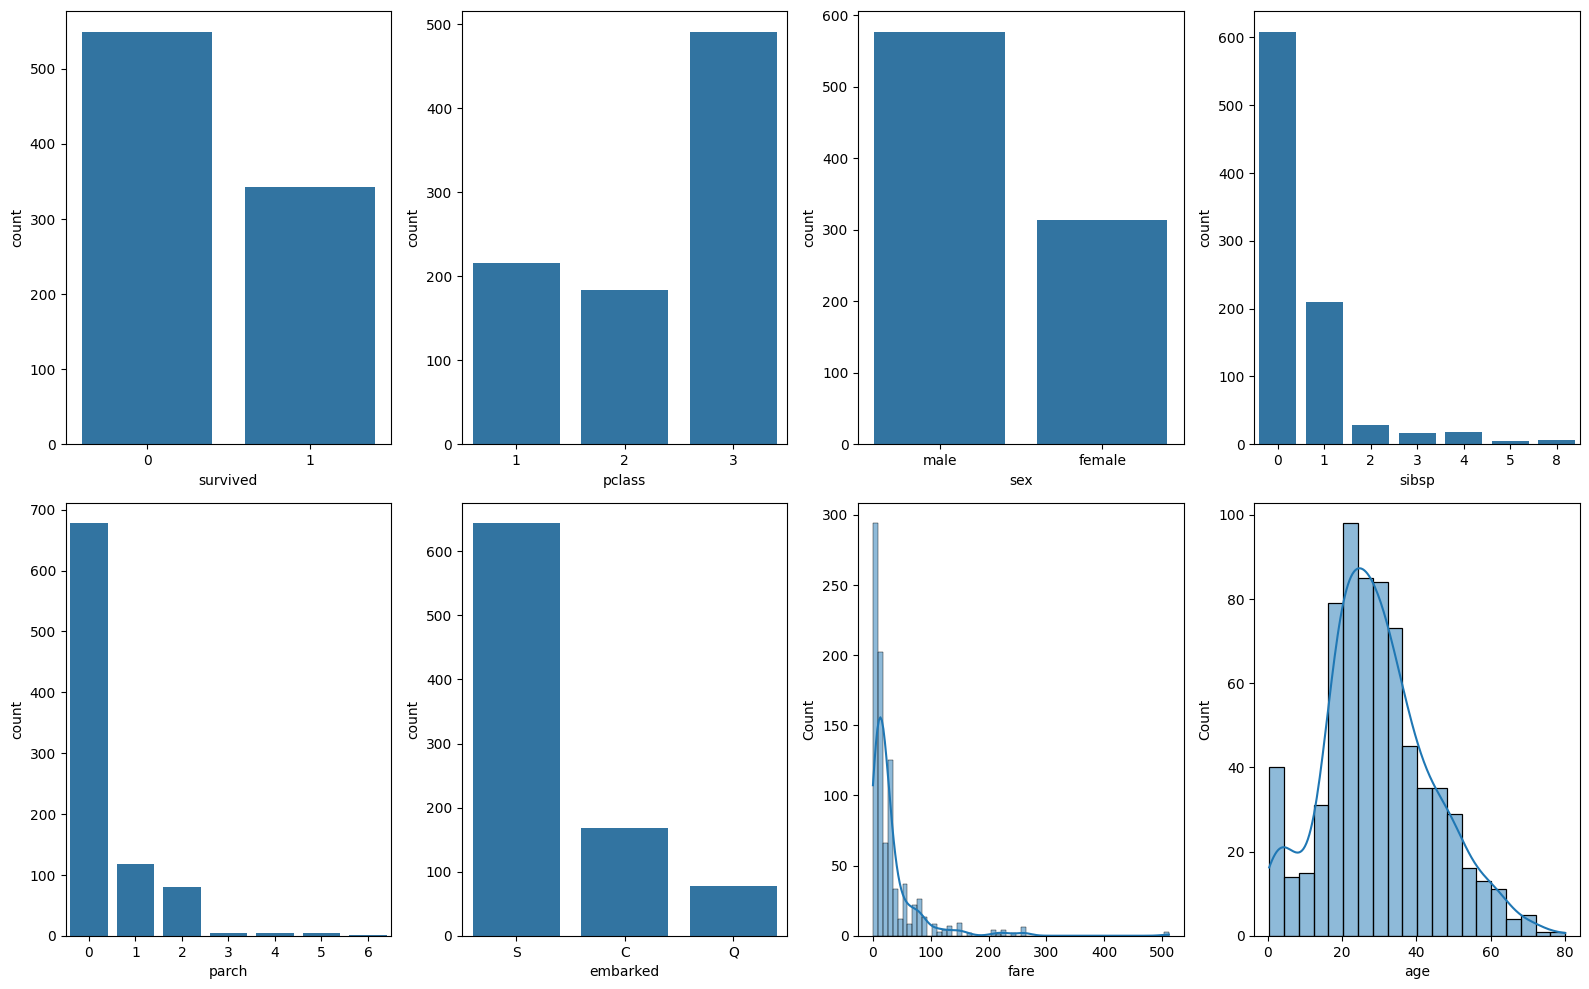

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))

sns.countplot(x='survived', data=titanic, ax=axes[0, 0])
sns.countplot(x='pclass', data=titanic, ax=axes[0, 1])
sns.countplot(x='sex', data=titanic, ax=axes[0, 2])
sns.countplot(x='sibsp', data=titanic, ax=axes[0, 3])
sns.countplot(x='parch', data=titanic, ax=axes[1, 0])
sns.countplot(x='embarked', data=titanic, ax=axes[1, 1])

sns.histplot(titanic['fare'], kde=True, ax=axes[1, 2])
sns.histplot(titanic['age'].dropna(), kde=True, ax=axes[1, 3])

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

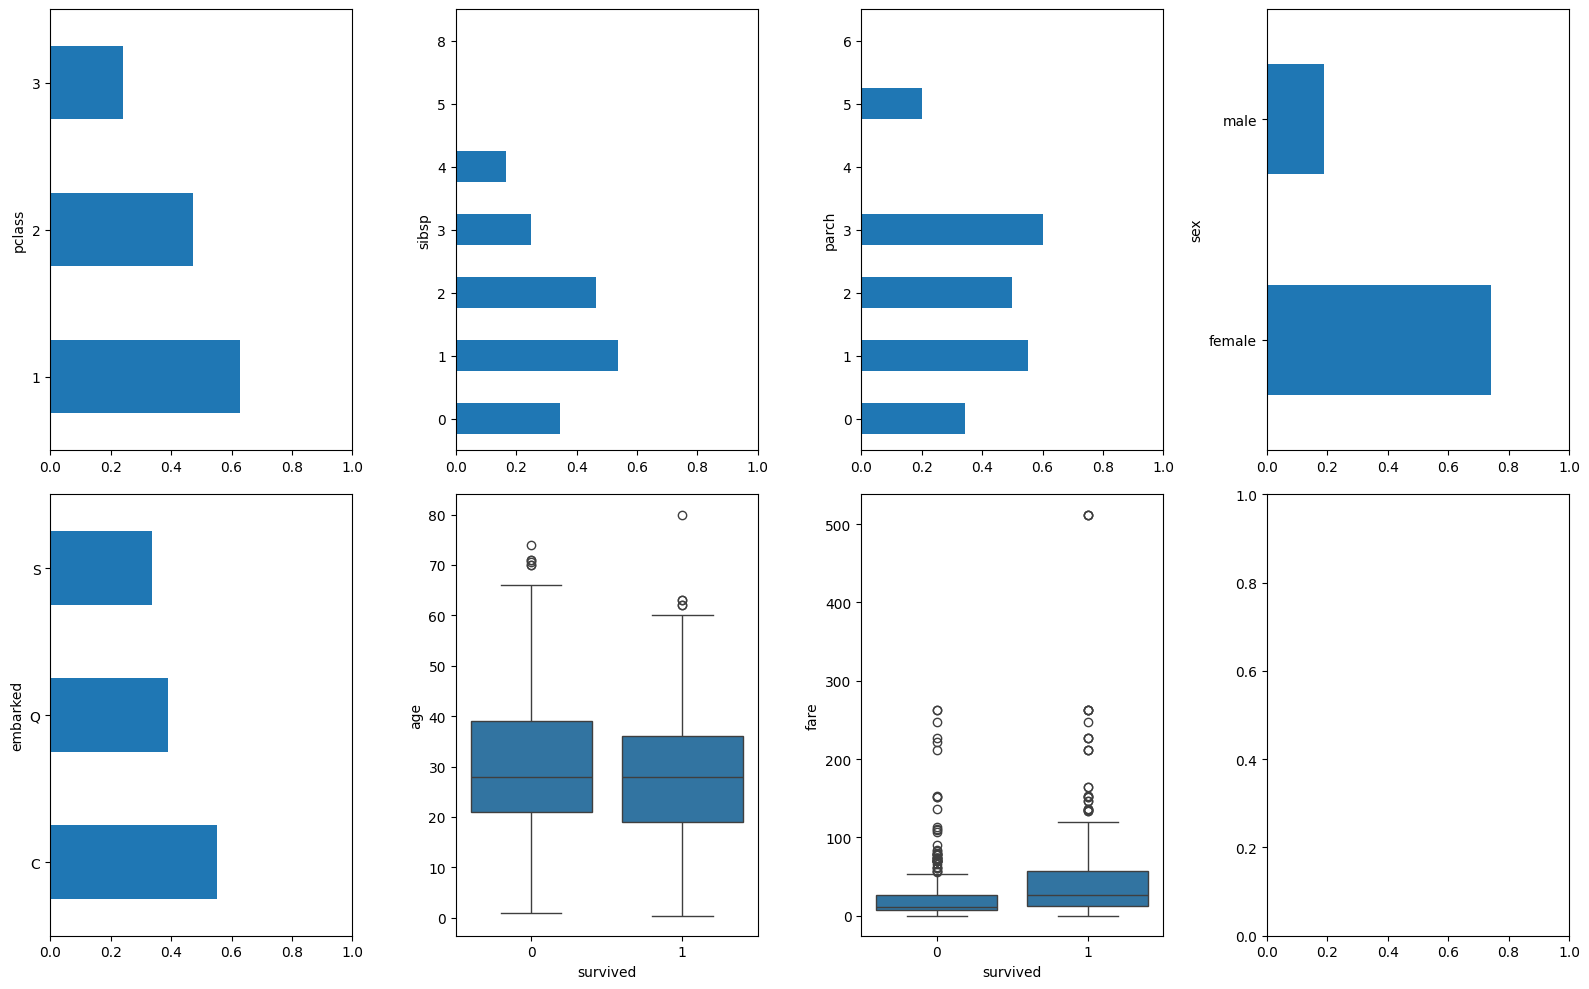

In [14]:
figbi, axesbi = plt.subplots(2, 4, figsize=(16, 10))
titanic.groupby('pclass')['survived'].mean().plot(kind='barh', ax=axesbi[0,0], xlim=[0,1])
titanic.groupby('sibsp')['survived'].mean().plot(kind='barh', ax=axesbi[0,1], xlim=[0,1])
titanic.groupby('parch')['survived'].mean().plot(kind='barh', ax=axesbi[0,2], xlim=[0,1])
titanic.groupby('sex')['survived'].mean().plot(kind='barh', ax=axesbi[0,3], xlim=[0,1])
titanic.groupby('embarked')['survived'].mean().plot(kind='barh', ax=axesbi[1,0], xlim=[0,1])
sns.boxplot(x="survived", y="age", data=titanic, ax=axesbi[1,1])
sns.boxplot(x="survived", y="fare", data=titanic, ax=axesbi[1,2])

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


## 7) 상관행렬 히트맵 및 다음 단계 (4강 §20~§22)

수치형 변수만 선택해 피어슨 상관계수를 계산하고 히트맵으로 시각화한다.

해석 원칙:
- 상관계수는 선형 관계의 요약치다.
- 상관이 높아도 인과를 의미하지 않는다.
- 범주형 변수는 인코딩 후 모델링 단계에서 추가 검증한다.

다음 단계(5강 연결):
1. 결측치 처리 전략 수립 (`age`, `embarked`, `deck`)
2. 범주형 인코딩 (`sex`, `embarked`, `class`)
3. 학습/검증 분리 후 분류 모델(Logistic Regression, Naive Bayes 등) 적용

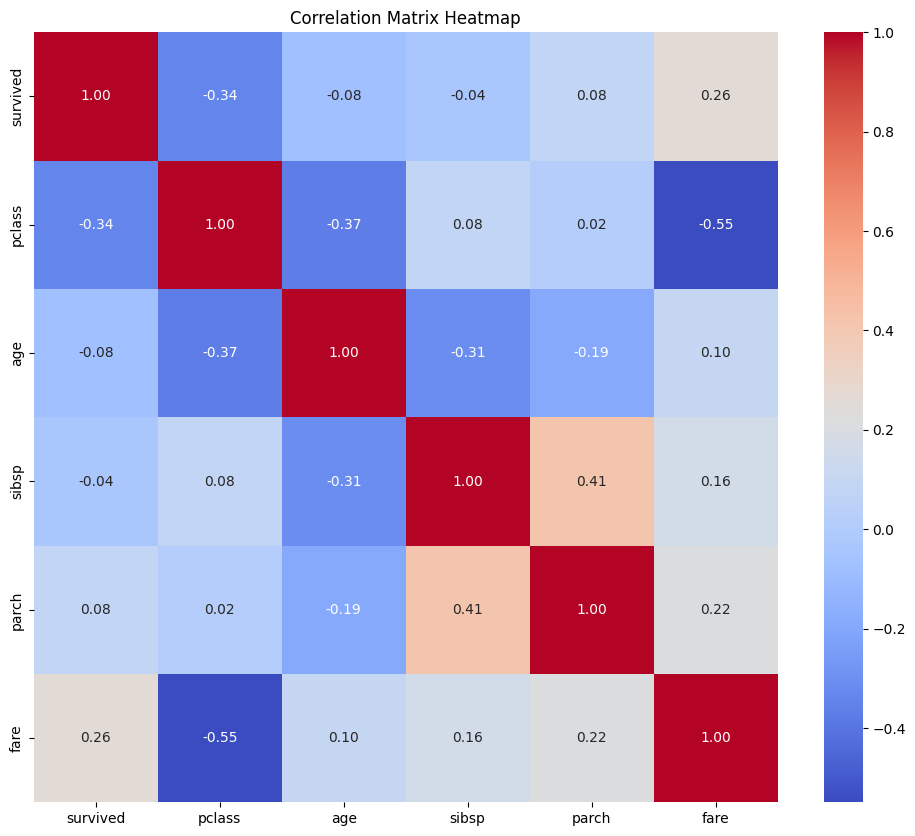

In [15]:
numeric_data = titanic.select_dtypes(include=[np.number])
# Calculate the correlation matrix
corr = numeric_data.corr()

# Plot a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

## 4강 최종 보강 정리 (수업 마무리)

### 오늘 수업 핵심 소구

- 이 노트북의 목적은 **모델 학습 이전 단계**에서 데이터를 정확히 이해하는 데 있다.
- `head -> info -> describe -> isnull -> datadict -> 시각화 -> 상관행렬` 흐름을 반복하면, 다른 데이터셋에서도 동일하게 적용 가능하다.

### 실무형 체크리스트 (반드시 확인)

- [ ] 타깃 변수와 설명 변수 정의 완료 (`survived` 기준)
- [ ] 결측치 현황 파악 완료 (`age`, `deck`, `embarked`, `embark_town`)
- [ ] 변수 타입 점검 완료 (`dtype` 기반 전처리 계획)
- [ ] 분포/빈도 시각화 완료 (`countplot`, `histplot`, `kde`)
- [ ] 관계 분석 완료 (`groupby`, `boxplot`, `heatmap`)
- [ ] 해석 원칙 확인 완료 (상관 != 인과)

### 다음 강의 연결(모델링 전환)

1. 결측치 처리 전략 수립 (삭제/대체/파생)
2. 범주형 인코딩 (Label/One-Hot)
3. 학습/검증 데이터 분리
4. 분류 모델 적용 및 평가 (예: Logistic Regression, Naive Bayes)

### 한 줄 결론

**EDA는 그래프를 그리는 단계가 아니라, 모델 성능을 좌우하는 데이터 이해 단계다.**